# EquiAlgo — audit of regional access

**Decision:** a transparent policy score, exact 40% grant budget, and a maximum 2-percentage-point regional selection gap. This is a hackathon prototype, not a validated lending system.

**Evidence boundary:** the jury's independent reference is unavailable. Historical accuracy measures reproduction of a biased committee. No 98% true-merit accuracy or hidden-reference equal-opportunity claim is made.

The provided starter notebook was executed unchanged first; see `artifacts/baseline_executed.ipynb`. All eight original files pass the organizer's SHA-256 manifest. Only the supplied synthetic dataset was used.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
from model_corrige import load_data, groups, verify_predictions
root = Path.cwd()
art = root / 'artifacts'
history, evaluation = load_data()
summary = json.loads((art / 'audit_summary.json').read_text())
display(pd.Series({k: summary[k] for k in ['historical_rows','evaluation_rows','holdout_rows','seed']}))
assert all(summary['original_files_intact'].values())
assert not (set(history.id_candidat) & set(evaluation.id_candidat))
assert history.isna().sum().sum() == evaluation.isna().sum().sum() == 0

historical_rows    10000
evaluation_rows     4000
holdout_rows        3000
seed                  42
dtype: int64

## 1. What the historical labels measure

`decision_octroi` records committee decisions, not independently established eligibility. Regional access differs despite an academic mean difference of less than one R-score point. We report the association within academic bands, without claiming causal identification or that academic score fully defines merit.

The split is 7,000 training / 3,000 held-out historical applicants, stratified by the historical decision, seed 42. Preprocessing and coefficient estimation use training rows only. Policy rules and the 0.02 parity tolerance are specified without looking at jury labels. Holding an exact batch budget uses candidate scores and group counts, never their outcomes.

,n,grant_rate,mean_r
group,,,
Centre,6000,0.483667,27.986927
Remote,4000,0.273000,27.326695


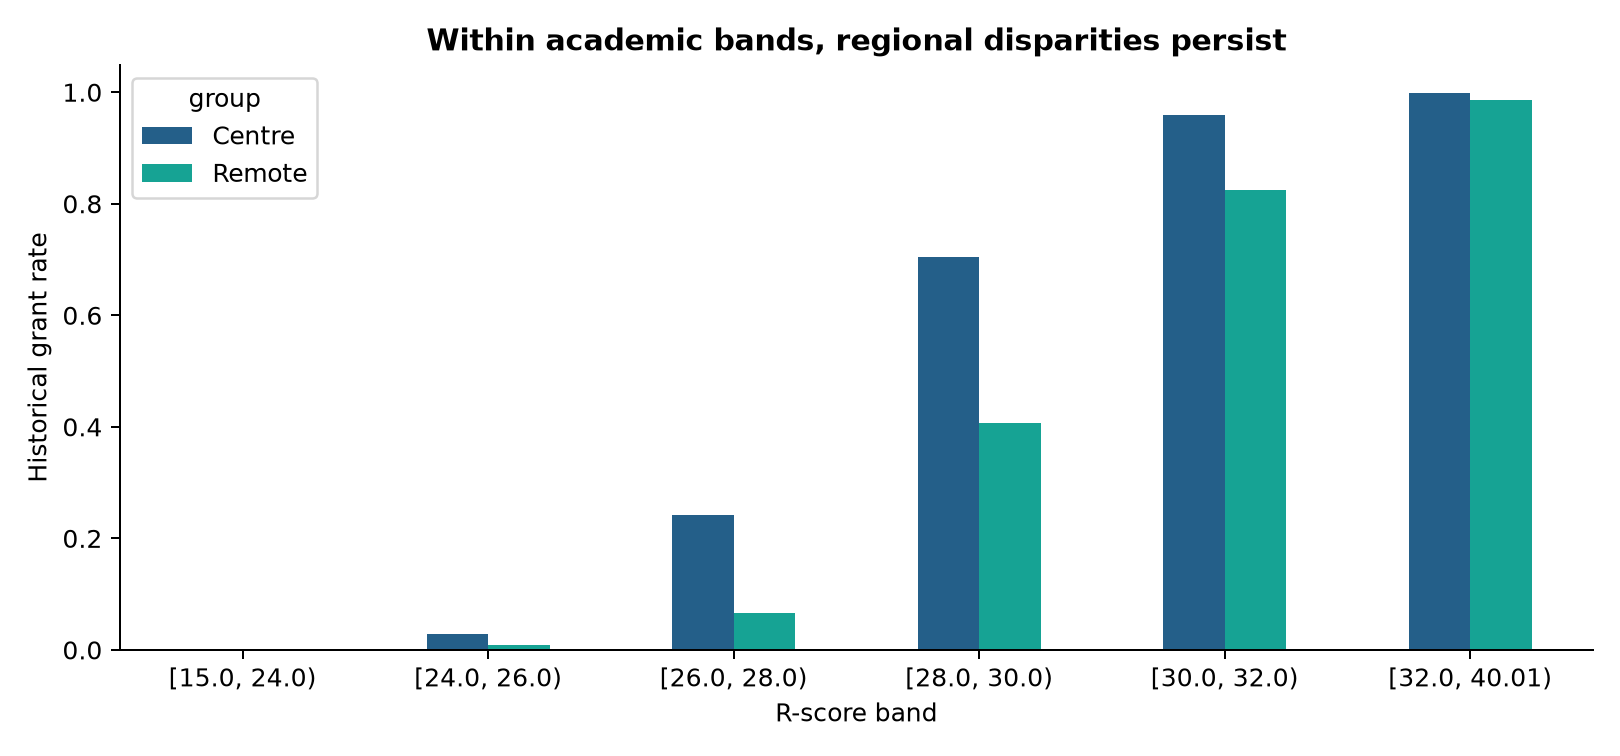

Academic-band standardized historical selection gap: 0.1392


In [2]:
display(history.assign(group=np.where(groups(history), 'Remote', 'Centre')).groupby('group').agg(
    n=('id_candidat','size'), grant_rate=('decision_octroi','mean'), mean_r=('cote_r_equivalent','mean')))
display(Image(filename=str(art / 'academic_bands.png')))
print('Academic-band standardized historical selection gap:', round(summary['academic_band_standardized_historical_gap'], 4))

## 2. Baseline and the proxy trap

Reproduce the supplied random forest (300 trees, leaf size 20, seed 42). Deleting region or region plus postal prefix leaves substantial disparity. Separate classifiers predict remote-region membership from each feature on the same held-out rows; ROC AUC near 1 indicates strong geographic information. AUC measures association, not whether a feature is inherently illegitimate: financial need and paid work can also be legitimate support criteria.

,historical_agreement,demographic_parity_gap,historical_tpr_gap,selection_rate
baseline,0.8813,0.1876,0.0628,0.3820
drop_region,0.8837,0.1805,0.0422,0.3843
drop_region_postal,0.8793,0.1731,0.0239,0.3947
corrected,0.8533,0.0000,0.1686,0.4000
controlled_logistic,0.8850,0.2317,0.1183,0.3983


,feature,remote_prediction_auc,remote_prediction_accuracy
0,code_postal_3,1.0000,1.0000
1,all_without_region,0.9999,0.9937
2,distance_domicile_campus_km,0.9973,0.9873
3,heures_travail_semaine,0.8063,0.7460
4,revenu_familial_estime,0.6977,0.6640
5,premiere_generation_universitaire,0.5873,0.6160
6,cote_r_equivalent,0.5523,0.5883
7,programme_etudes,0.5476,0.5917


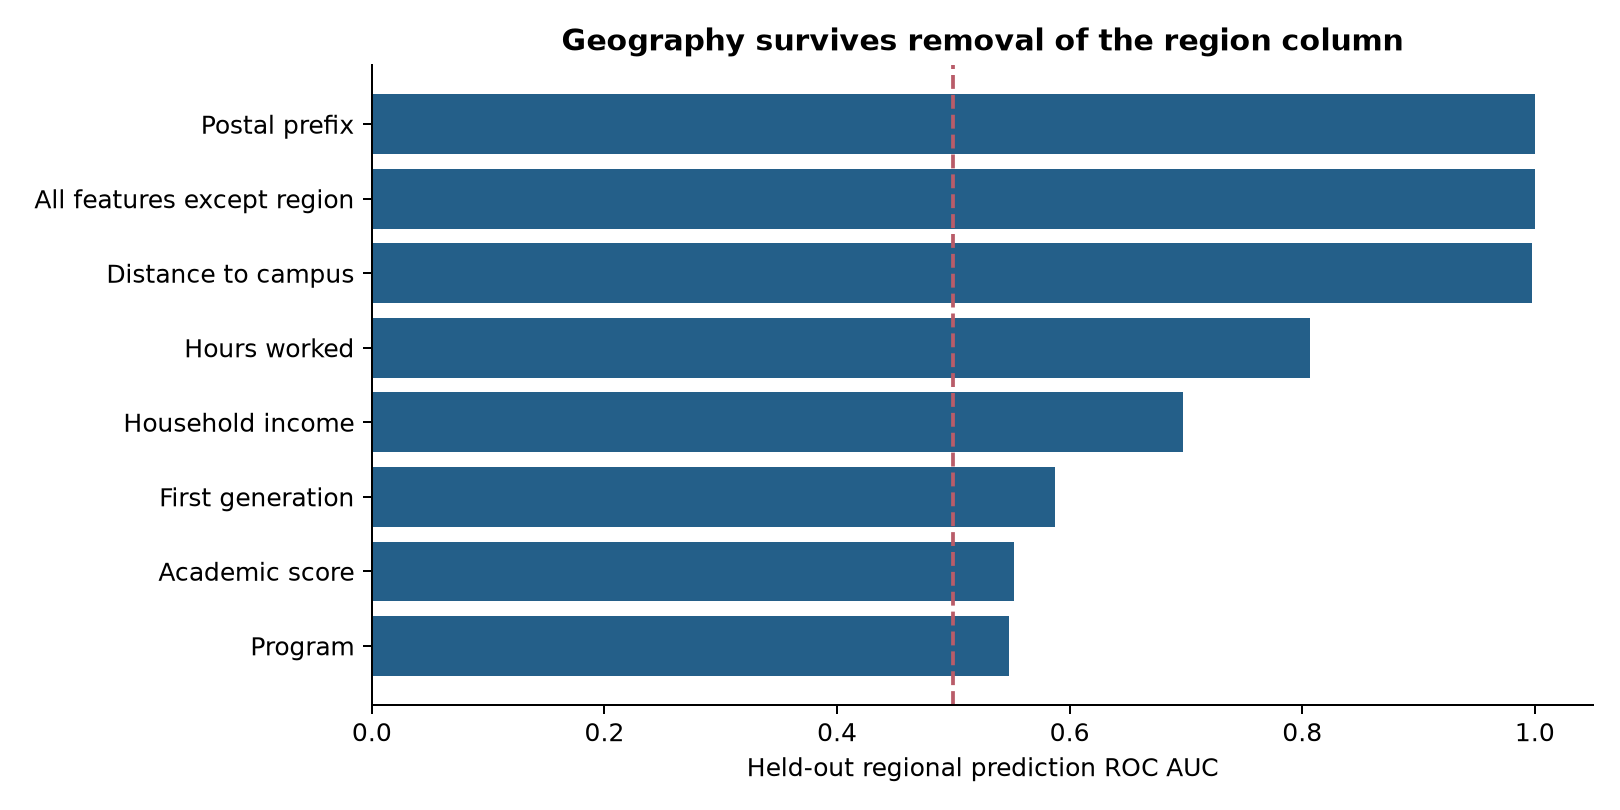

In [3]:
metrics = pd.DataFrame({k:{a:b for a,b in v.items() if a != 'ci_95'} for k,v in summary['holdout_metrics'].items()}).T
display(metrics[['historical_agreement','demographic_parity_gap','historical_tpr_gap','selection_rate']].round(4))
display(pd.read_csv(art / 'proxy_audit.csv').round(4))
display(Image(filename=str(art / 'proxy_signals.png')))

## 3. Fairness objective and what is observable

Our ultimate objective is **equal opportunity relative to independent merit**: |P(grant=1 | merit=1, centre) − P(grant=1 | merit=1, remote)|. This quantity cannot be measured without valid merit labels. Historical true-positive-rate gaps are shown only to diagnose label dependence.

For this submission, the implemented fairness constraint is **demographic parity within 0.02**, |P(grant=1 | centre) − P(grant=1 | remote)| ≤ 0.02, with exactly 40% funded. This is an observable, provisional access safeguard, not a substitute proof of equal opportunity. We choose it because constraining TPR against known-biased labels can entrench historical exclusions. Cohort profiles can justify different selection rates; this choice therefore requires human governance and sensitivity analysis.

The brief warns that parity and equal opportunity can conflict. This is a trade-off, not a universal impossibility theorem: both can hold for some distributions and classifiers. See [Fairlearn's metric definitions](https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html).

## 4. Correction and feature policy

1. Estimate a regularized additive logistic model of committee decisions, controlling for region, study program, distance, wealth, work and first-generation status.
2. Build a new ranking score from the fitted associations: academic score and work have nonnegative coefficients; wealth cannot increase priority; first-generation status cannot reduce it. Region, postal prefix, distance and program have zero ranking contribution. These are explicit normative choices, not discovered true-merit labels.
3. Enumerate feasible numbers of grants in each regional block. For each count, take the highest policy scores within the block. Choose the maximum summed score subject to 40% total grants and the parity bound. This is an exact solution to the specified two-group batch optimization. A stable seeded hash resolves exact ties.

Region remains available for auditing and allocation constraints. The system is not 'region blind'. Counterfactual score invariance does not imply counterfactual decision invariance because allocation depends on regional membership. The positive work coefficient may disadvantage students unable to work; treat it as a hypothesis to review. Removing a wealth advantage does not establish the correct financial-need benefit.

,feature,historical_coefficient_standardized,policy_coefficient_standardized,policy_coefficient_raw
0,cote_r_equivalent,4.12194,4.12194,1.38355
1,revenu_familial_estime,0.74091,0.00000,0.00000
2,heures_travail_semaine,0.74662,0.74662,0.19690
3,distance_domicile_campus_km,0.11286,0.00000,0.00000
4,premiere_generation_universitaire,-0.09505,0.00000,0.00000
5,programme_etudes_Genie,0.04268,0.00000,0.00000
6,programme_etudes_Sante,0.06498,0.00000,0.00000
7,programme_etudes_Sciences,0.03881,0.00000,0.00000
8,programme_etudes_Sciences sociales,0.01111,0.00000,0.00000
9,region_administrative_Capitale-Nationale,0.80480,0.00000,0.00000


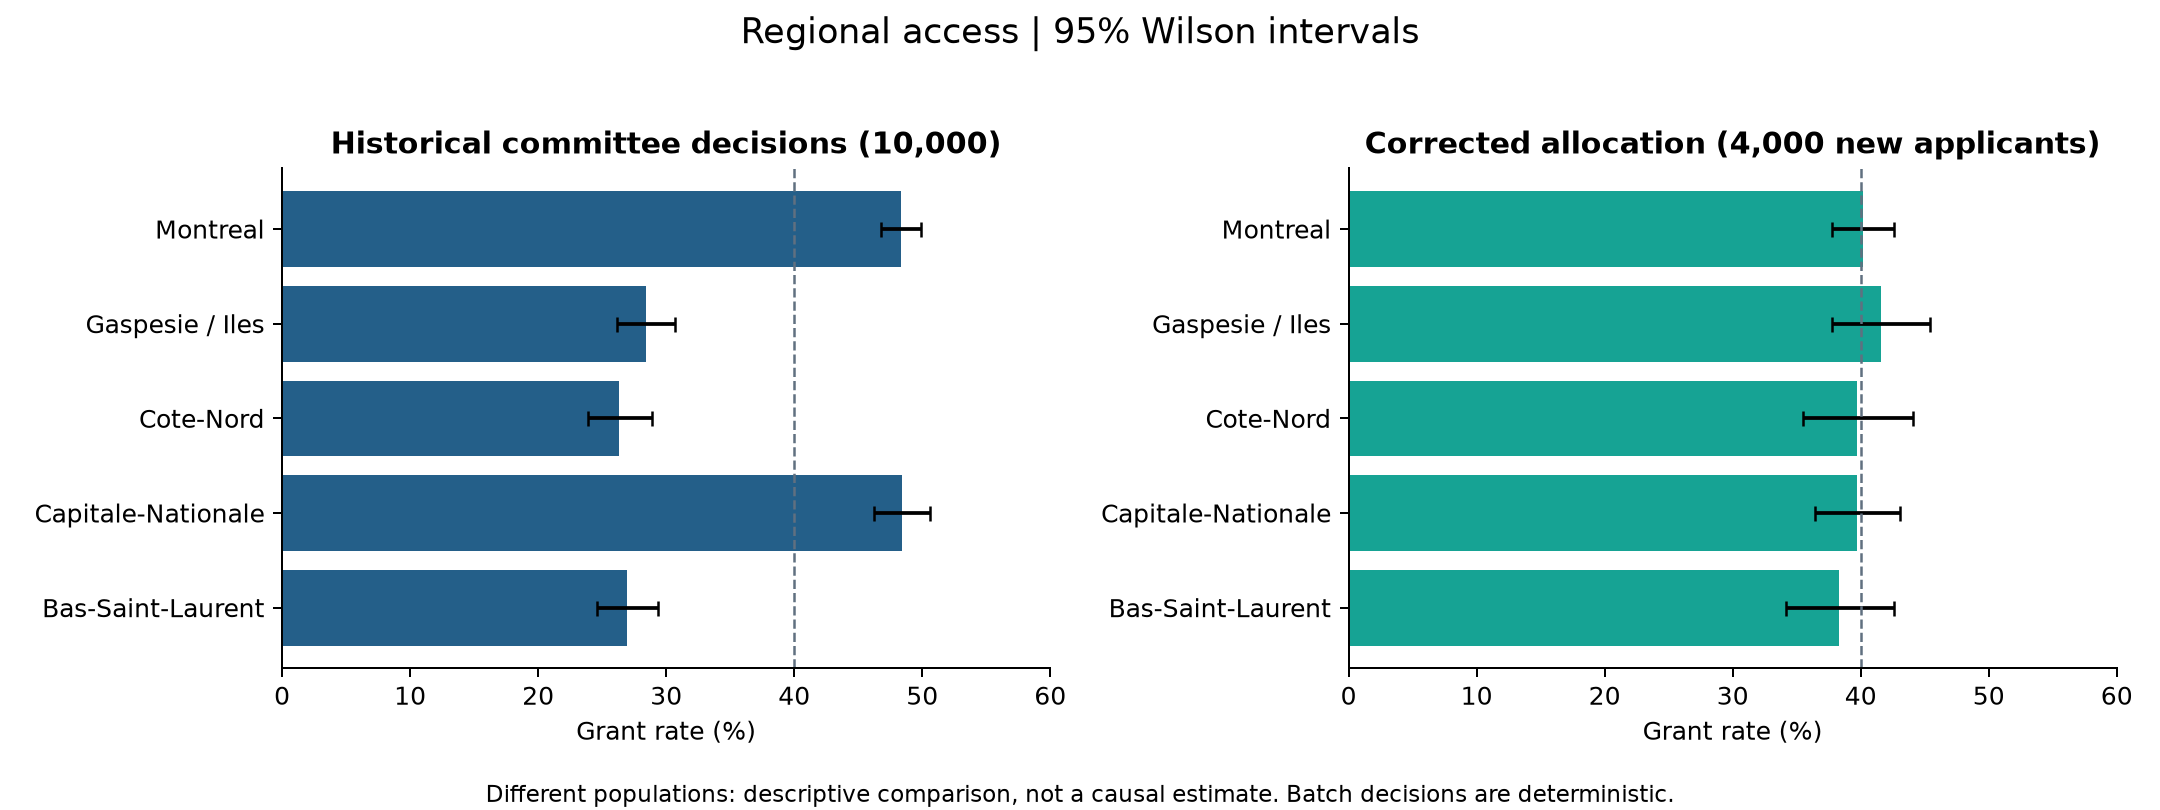

,sample,region,n,grants,rate,ci_low,ci_high
0,historical decisions,Bas-Saint-Laurent,1293,348,0.2691,0.2457,0.2940
1,historical decisions,Capitale-Nationale,1999,968,0.4842,0.4624,0.5062
2,historical decisions,Cote-Nord,1178,310,0.2632,0.2388,0.2890
3,historical decisions,Gaspesie-Iles-de-la-Madeleine,1529,434,0.2838,0.2618,0.3070
4,historical decisions,Montreal,4001,1934,0.4834,0.4679,0.4989
5,evaluation corrected,Bas-Saint-Laurent,504,193,0.3829,0.3415,0.4261
6,evaluation corrected,Capitale-Nationale,821,326,0.3971,0.3642,0.4310
7,evaluation corrected,Cote-Nord,491,195,0.3971,0.3548,0.4411
8,evaluation corrected,Gaspesie-Iles-de-la-Madeleine,633,263,0.4155,0.3777,0.4543
9,evaluation corrected,Montreal,1551,623,0.4017,0.3776,0.4263


In [4]:
display(pd.read_csv(art / 'coefficients.csv').round(5))
display(Image(filename=str(art / 'regional_access.png')))
display(pd.read_csv(art / 'regional_rates.csv').round(4))

## 5. Pareto sweep and uncertainty

The 12 parity tolerances are 1.0, .25, .20, .15, .10, .075, .05, .03, .02, .01, .005 and .001, each with the exact 40% budget. We sweep both the baseline probability score and the repaired score. Circles mark nondominated points in the measured historical-agreement/parity plane. Historical agreement is a descriptive comparator, not our optimization target or a hidden-reference utility estimate. Several constraints can produce identical decisions when they are inactive.

The second panel measures loss of the stated policy ranking objective. Neither panel establishes the unknown jury Pareto front. The default .02 guardrail is a policy choice, not a holdout-selected optimum.

Intervals below are 500 stratified bootstrap replicates, conditional on fitted models and fixed outcomes/group strata. They do not cover label bias, causal uncertainty or retraining variability. Wilson regional-rate intervals illustrate sampling uncertainty for future applicants; the current batch's counts are exact.

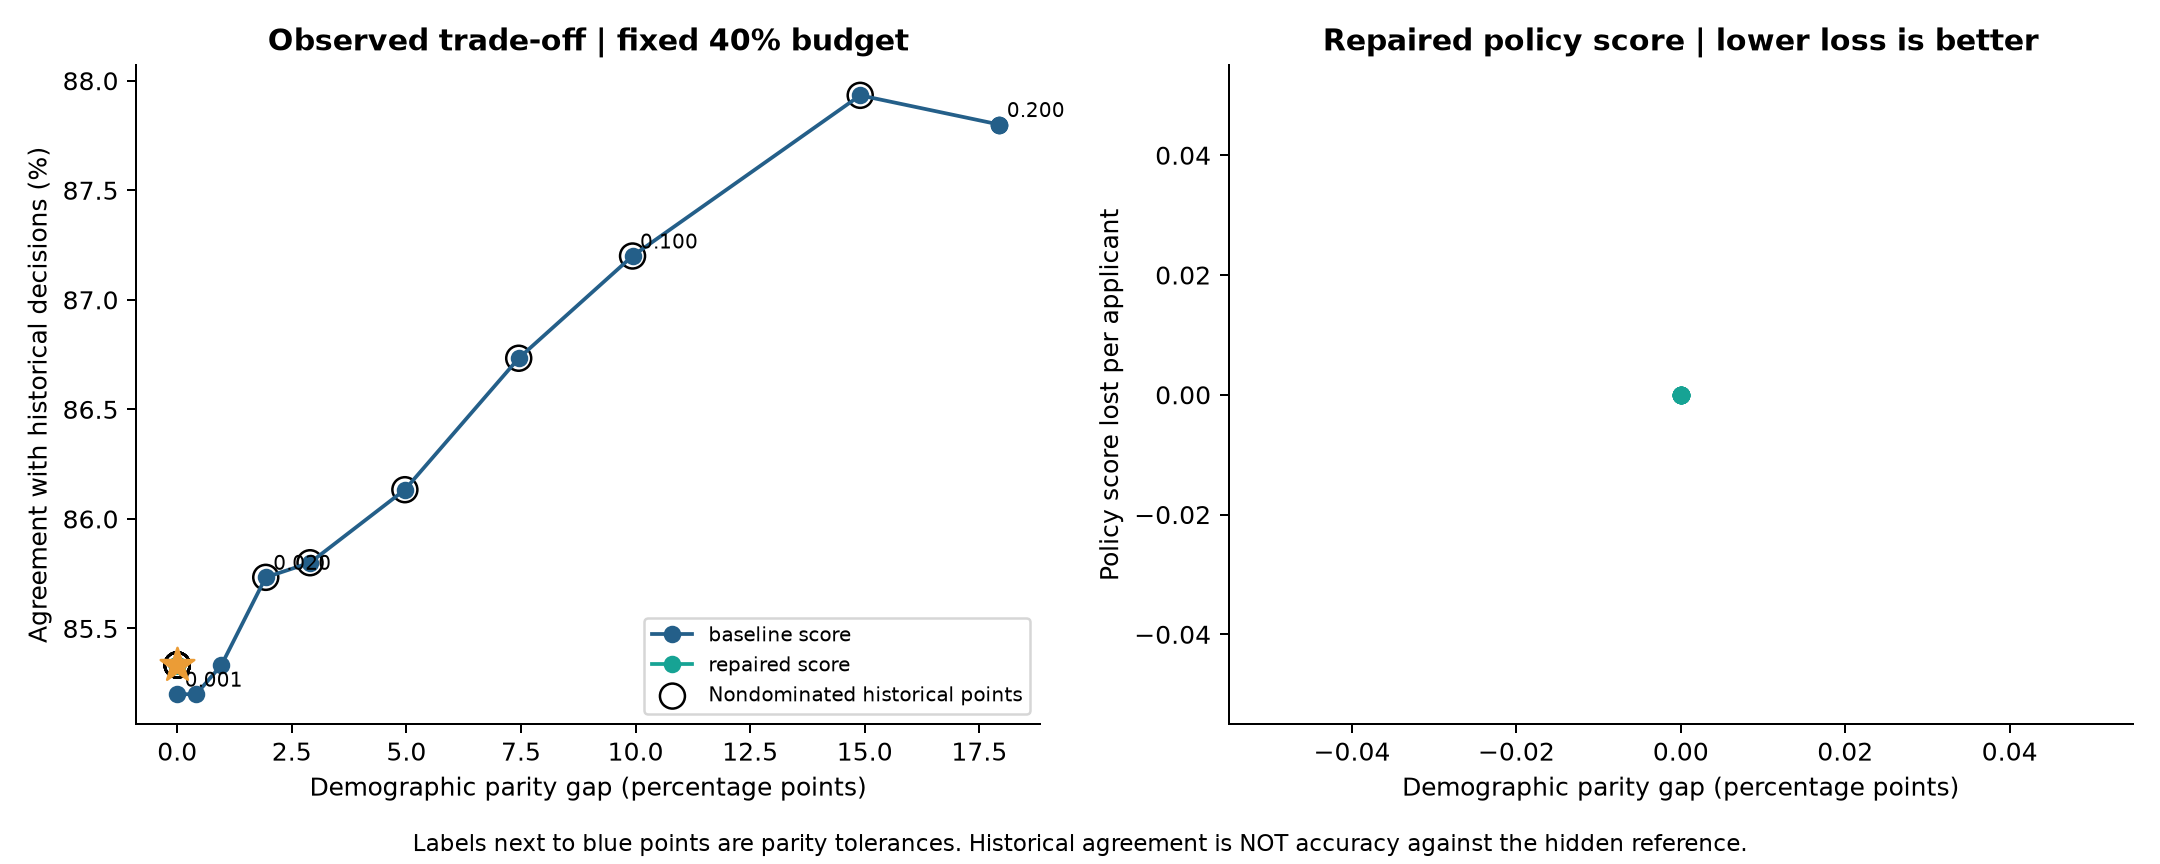

,method,max_gap,historical_agreement,historical_macro_f1,selection_rate,centre_selection,remote_selection,demographic_parity_gap,historical_tpr_centre,historical_tpr_remote,historical_tpr_gap,historical_fpr_centre,historical_fpr_remote,ranking_utility_loss,historical_pareto
0,baseline score,1.000,0.8780,0.8729,0.4,0.4732,0.2939,0.1794,0.8556,0.8289,0.0267,0.1146,0.0892,0.0000,False
1,baseline score,0.250,0.8780,0.8729,0.4,0.4732,0.2939,0.1794,0.8556,0.8289,0.0267,0.1146,0.0892,0.0000,False
2,baseline score,0.200,0.8780,0.8729,0.4,0.4732,0.2939,0.1794,0.8556,0.8289,0.0267,0.1146,0.0892,0.0000,False
3,baseline score,0.150,0.8793,0.8743,0.4,0.4608,0.3118,0.1490,0.8510,0.8466,0.0044,0.0950,0.1072,0.0003,True
4,baseline score,0.100,0.8720,0.8666,0.4,0.4406,0.3412,0.0993,0.8265,0.8761,0.0496,0.0786,0.1366,0.0024,True
5,baseline score,0.075,0.8673,0.8618,0.4,0.4304,0.3559,0.0745,0.8102,0.8968,0.0865,0.0742,0.1490,0.0041,True
6,baseline score,0.050,0.8613,0.8555,0.4,0.4203,0.3706,0.0497,0.7939,0.9115,0.1176,0.0699,0.1637,0.0062,True
7,baseline score,0.030,0.8580,0.8520,0.4,0.4118,0.3829,0.0290,0.7811,0.9292,0.1481,0.0655,0.1738,0.0082,True
8,baseline score,0.020,0.8573,0.8513,0.4,0.4079,0.3886,0.0193,0.7765,0.9381,0.1616,0.0622,0.1783,0.0091,True
9,baseline score,0.010,0.8533,0.8472,0.4,0.4039,0.3943,0.0097,0.7683,0.9410,0.1727,0.0622,0.1851,0.0102,False


,baseline,corrected
historical_agreement,"[0.8691583333333334, 0.8925083333333333]","[0.840475, 0.8665083333333333]"
demographic_parity_gap,"[0.1658718022420236, 0.2104371945961483]","[0.0, 0.02617361310721469]"
historical_tpr_gap,"[0.01219175071514176, 0.11079031322007825]","[0.12923204247238165, 0.20704942634125567]"


In [5]:
display(Image(filename=str(art / 'pareto_front.png')))
display(pd.read_csv(art / 'pareto.csv').round(4))
display(pd.DataFrame({name: summary['holdout_metrics'][name]['ci_95'] for name in ['baseline','corrected']}))

## 6. Sensitivity, intersections and remaining risks

The following scenarios are explicit alternative value judgments: academic priority alone, the learned work credit, additional financial-need credit, and first-generation support. We compare selections and TPR under these **hypothetical** eligibility rules. They are not independent validation labels and must not be presented as merit accuracy.

Five training bootstrap refits measure decision stability, not correctness. Regional × program × first-generation rates expose harms hidden by two-group averages. Cells below 30 are flagged; use wider time windows and uncertainty intervals before intervention. Academic bands are coarse, hidden determinants may remain, and association cannot identify discrimination by itself. Increasing a feature that has zero weight leaves the individual score unchanged; increasing academic score cannot reduce it, holding other inputs fixed.

In [6]:
display(pd.read_csv(art / 'assumption_sensitivity.csv'))
display(pd.read_csv(art / 'fit_stability.csv'))
display(pd.read_csv(art / 'intersection_audit.csv'))
display(pd.read_csv(art / 'data_drift.csv'))

,assumed_policy,decision_overlap,tpr_gap_under_assumption,changed_decisions
0,academic_only,0.9440,0.080444,224
1,learned_work_credit,1.0000,0.000000,0
2,add_mild_financial_need,0.9625,0.033435,150
3,add_stronger_financial_need,0.9195,0.065876,322
4,add_first_generation_support,0.9650,0.010286,140


,bootstrap_seed,decision_overlap,changed_decisions,grant_rate
0,7,0.9965,14,0.4
1,42,0.9995,2,0.4
2,123,0.9970,12,0.4
3,2026,0.9985,6,0.4
4,8675309,1.0000,0,0.4


,region_administrative,premiere_generation_universitaire,programme_etudes,size,sum,mean,small_cell
0,Bas-Saint-Laurent,0,Arts et lettres,54,22,0.407407,False
1,Bas-Saint-Laurent,0,Genie,60,23,0.383333,False
2,Bas-Saint-Laurent,0,Sante,47,14,0.297872,False
3,Bas-Saint-Laurent,0,Sciences,64,26,0.406250,False
4,Bas-Saint-Laurent,0,Sciences sociales,49,14,0.285714,False
5,Bas-Saint-Laurent,1,Arts et lettres,58,20,0.344828,False
6,Bas-Saint-Laurent,1,Genie,40,19,0.475000,False
7,Bas-Saint-Laurent,1,Sante,34,16,0.470588,False
8,Bas-Saint-Laurent,1,Sciences,43,20,0.465116,False
9,Bas-Saint-Laurent,1,Sciences sociales,55,19,0.345455,False


,feature,history_mean,evaluation_mean,standardized_mean_shift
0,cote_r_equivalent,27.722834,27.798895,0.025320
1,revenu_familial_estime,68165.901400,68754.102000,0.018330
2,heures_travail_semaine,10.591000,10.606250,0.004007
3,distance_domicile_campus_km,100.457070,101.825275,0.011299
4,premiere_generation_universitaire,0.336500,0.342250,0.012168


## 7. Production governance and appeals

See `MONITORING.md` for owners, denominators, alert thresholds, independent relabeling, review workflows, privacy controls and rollback. Before deployment, a geographically diverse panel must independently adjudicate a representative sample, blinded to previous decisions where feasible. Both funded and rejected applicants must be sampled to reduce selective-label bias. Only then can true-reference accuracy, calibration and equal opportunity be estimated.

An appeal is reviewed by a human who can inspect data corrections and contextual barriers; a review must not silently increase the fixed grant budget or automatically revoke another student's award. Freeze releases on severe issues and use an approved human allocation process, not an automatic return to the biased baseline.

In [7]:
submission = pd.read_csv(root / 'predictions.csv')
display(pd.Series(verify_predictions(evaluation, submission)))
assert submission.decision_octroi.sum() == 1600
assert verify_predictions(evaluation, submission)['demographic_parity_gap'] <= 0.02
print('Hidden-reference accuracy: unavailable. The requested 98% is not verified.')

rows                                                                            4000
grants                                                                          1600
grant_rate                                                                       0.4
selection_rate_centre                                                       0.400084
selection_rate_remote                                                       0.399877
demographic_parity_gap                                                      0.000207
reference_accuracy                                                              None
reference_equal_opportunity_gap                                                 None
status                             Format, IDs and budget valid; hidden-reference...
dtype: object

Hidden-reference accuracy: unavailable. The requested 98% is not verified.


## Sources and reproducibility

- Organizer: supplied `README.md`, `consignes-en.pdf`, `consignes-fr.pdf`, starter notebook and manifest.
- [HxBuddy IVADO track](https://hxbuddy.ca/), [public track text](https://hxbuddy.ca/demo-locales/en.json), retrieved 2026-10-03: indicative macro F1/accuracy; final jury uses the supplied rubric; Devpost requires the matching prize and team identity.
- [Fairlearn metric definitions](https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html) and [postprocessing](https://fairlearn.org/main/user_guide/mitigation/postprocessing.html).
- Tools: Python, NumPy, pandas, SciPy, scikit-learn, Matplotlib, Fairlearn (starter), Jupyter and ReportLab. OpenAI Codex assisted with analysis, code and documentation. No external training dataset or pretrained predictive model was used.

Run `python model_corrige.py`, `python build_audit.py`, `python build_presentation.py`, and `python -m unittest discover -s tests`. The checked-in notebook already contains results. Exact package versions and split IDs are in `artifacts/`.